In [1]:
# libraries
from tensorflow.keras.datasets import mnist #import mnist dataset from keras API
import numpy as np
import matplotlib.pyplot as plt

#DATA LOADING 2.1

# load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# labels flattened
y_train = y_train.flatten()
y_test = y_test.flatten()

# full data training and testing before splitting
X_train = X_train[:60000]  # full training set is 60000 in keras
y_train = y_train[:60000]
X_test = X_test[:10000]  # full test set is 10000 in keras
y_test = y_test[:10000]

# split training data into train %80 and validation %20. -> 48000/60000
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=0)

# display dataset shapes
print("Training set shape:", X_train.shape, "Labels:", y_train.shape) #checking labels after splitting
print("Validation set shape:", X_val.shape, "Labels:", y_val.shape)
print("Test set shape:", X_test.shape, "Labels:", y_test.shape)





11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training set shape: (48000, 28, 28) Labels: (48000,)
Validation set shape: (12000, 28, 28) Labels: (12000,)
Test set shape: (10000, 28, 28) Labels: (10000,)


In [2]:
#DATA ANALYSIS 2.2
# already imported but
import numpy as np
import matplotlib.pyplot as plt

#2.2.2
# basic statistics : mean and standard deviation values


print("Mean pixel value:", np.mean(X_train))
print("Standard deviation:", np.std(X_train))


Mean pixel value: 33.28194106079932
Standard deviation: 78.5240131616269


Class Distribution: {0: 4738, 1: 5394, 2: 4766, 3: 4905, 4: 4674, 5: 4337, 6: 4734, 7: 5012, 8: 4681, 9: 4759}


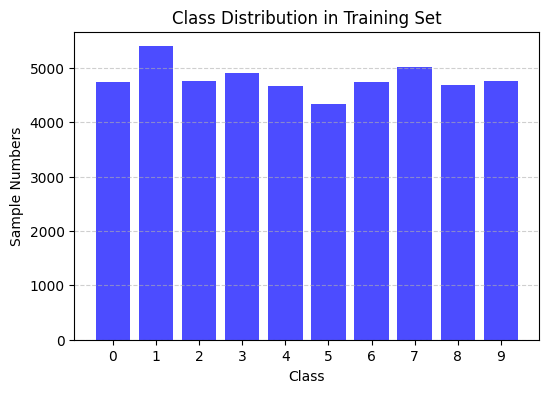

In [3]:
#2.2.1
# class distributions outputting
unique, counts = np.unique(y_train, return_counts=True)
class_distribution = dict(zip(unique, counts))

print("Class Distribution:", class_distribution)

# display the class distribution like in recitatiopn
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(unique, counts, color="blue", alpha=0.7) #blue
plt.xlabel("Class")
plt.ylabel("Sample Numbers")
plt.title("Class Distribution in Training Set")
plt.xticks(unique)  #to output all labels in graph
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

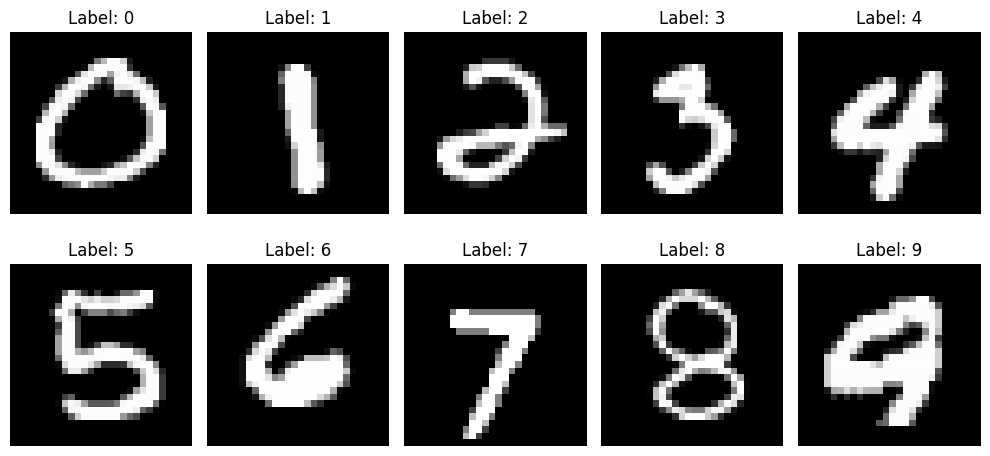

In [6]:
#2.2.3
# visualization sample images for all labels with subplots
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.flatten()

#like in recit
for i in range(10):
    img = X_train[y_train == i][0]  # select first image of each digit
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Label: {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [12]:
#DATA PREPROCESSING 2.3
#computing mean and standard deviation again
mean = np.mean(X_train, axis=(0, 1, 2))  # compute mean for each channel like in recit
std = np.std(X_train, axis=(0, 1, 2))    # comoute standard deviation for each channel like in recit but we have single channel so others will stay unused


print("mean array:", mean.shape)
print("std array:", std.shape)
#BUT WE HAVE SINGLE CHANNEL SO ITS ()

# normalizations using NumPy. (X- mean) / std
X_train_norm = (X_train - mean) / std
X_val_norm = (X_val - mean) / std
X_test_norm = (X_test - mean) / std

# printing before and after normalization
print("\nMean before NumPy normalization:", np.mean(X_train, axis=(0, 1, 2)))
print("Std before NumPy normalization:", np.std(X_train, axis=(0, 1, 2)))

print("\nMean after NumPy normalization:", np.mean(X_train_norm, axis=(0, 1, 2))) #should be so so close to 0
print("Std after NumPy normalization:", np.std(X_train_norm, axis=(0, 1, 2))) # should be so so close to 1



mean array: ()
std array: ()

Mean before NumPy normalization: 33.28194106079932
Std before NumPy normalization: 78.5240131616269

Mean after NumPy normalization: -2.0636931317258563e-17
Std after NumPy normalization: 1.0000000000000013


X_train_norm shape: (48000, 28, 28)
X_train_flat shape: (48000, 784)
k=1 -> Validation Accuracy: 0.9745
k=3 -> Validation Accuracy: 0.9731
k=5 -> Validation Accuracy: 0.9723
k=7 -> Validation Accuracy: 0.9716
k=9 -> Validation Accuracy: 0.9699

Best k: 1 with Validation Accuracy: 0.9745


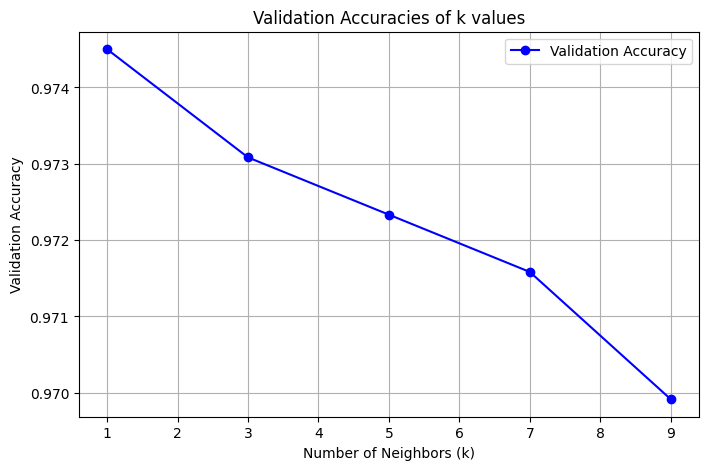

In [13]:
#kNN CLASSIFYING PART 3
#3.1 Model Initialization and Hyperparameter Tuning


# convert 3d to 2d for knn
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_val_flat = X_val_norm.reshape(X_val_norm.shape[0], -1)
X_test_flat = X_test_norm.reshape(X_test_norm.shape[0], -1)


print("X_train_norm shape:", X_train_norm.shape)
print("X_train_flat shape:", X_train_flat.shape)

# init hyperparameters
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

k_values = [1, 3, 5, 7, 9]  # k values
best_k = None
best_accuracy = 0
validation_accuracies = []

# train for diffrerent k values
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")  # use euclidian
    knn.fit(X_train_flat, y_train)

    # evaluate
    y_val_pred = knn.predict(X_val_flat) #use flat x value with knn prediction and take y_val_pred as in recit
    value_accuracy = accuracy_score(y_val, y_val_pred)

    # store the results
    validation_accuracies.append((k, value_accuracy))
    print(f"k={k} -> Validation Accuracy: {value_accuracy:.4f}")

    # update best
    if value_accuracy > best_accuracy:
        best_k = k
        best_accuracy = value_accuracy


# print best k value and accuracy
print(f"\nBest k: {best_k} with Validation Accuracy: {best_accuracy:.4f}")

# plotting lastly the k values and its validation accuracy
plt.figure(figsize=(8, 5))
plt.plot([v[0] for v in validation_accuracies], [v[1] for v in validation_accuracies], marker='o', linestyle='-', color='b', label="Validation Accuracy")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracies of k values")
plt.legend()
plt.grid(True)
plt.show()










In [21]:
#Final model training and evaluation 3.2
# 3.2 Final Model Training and Evaluation

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# training and validation
X_train_final = np.concatenate((X_train_flat, X_val_flat), axis=0)
y_train_final = np.concatenate((y_train, y_val), axis=0)

# Train final model using the best k and metric
final_knn = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean")  #  euclidean distance
final_knn.fit(X_train_final, y_train_final)

# eval on the test set
y_test_pred = final_knn.predict(X_test_flat)

# accuracy value 3.2.1
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy with Best Hyperparameters (k={best_k}, metric='euclidean'): {test_accuracy:.4f}")


# classification report final evaluation 3.2.2
class_names = [str(i) for i in range(10)]  # Digits 0-9
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=class_names)) #as in recitation



Test Accuracy with Best Hyperparameters (k=1, metric='euclidean'): 0.9691

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.97      0.99      0.98      1135
           2       0.98      0.96      0.97      1032
           3       0.96      0.96      0.96      1010
           4       0.97      0.96      0.97       982
           5       0.95      0.96      0.96       892
           6       0.98      0.99      0.98       958
           7       0.96      0.96      0.96      1028
           8       0.98      0.94      0.96       974
           9       0.96      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



Confusion Matrix for KNN:
[[ 973    1    1    0    0    1    3    1    0    0]
 [   0 1129    3    0    1    1    1    0    0    0]
 [   7    6  992    5    1    0    2   16    3    0]
 [   0    1    2  970    1   19    0    7    7    3]
 [   0    7    0    0  944    0    3    5    1   22]
 [   1    1    0   12    2  860    5    1    6    4]
 [   4    2    0    0    3    5  944    0    0    0]
 [   0   14    6    2    4    0    0  992    0   10]
 [   6    1    3   14    5   13    3    4  920    5]
 [   2    5    1    6   10    5    1   11    1  967]]


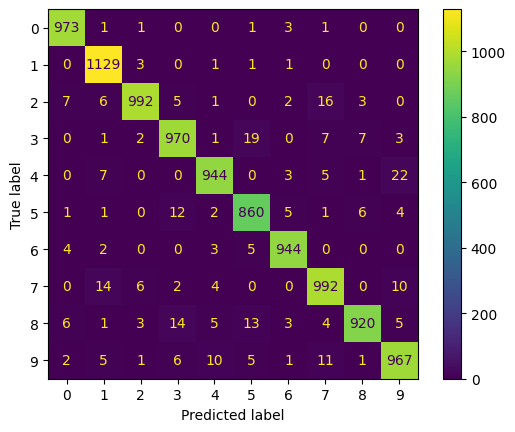

In [11]:
# generate and visualize confusion matrix 3.2.3
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix for KNN:")
print(cm)

# We can visualize the confusion matrix : in recitation we are using ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_test_pred)


Most Frequently Misclassified Digits in order: [8 9 3 2 4 7 5 6 0 1]

5 random misclassifed examples:


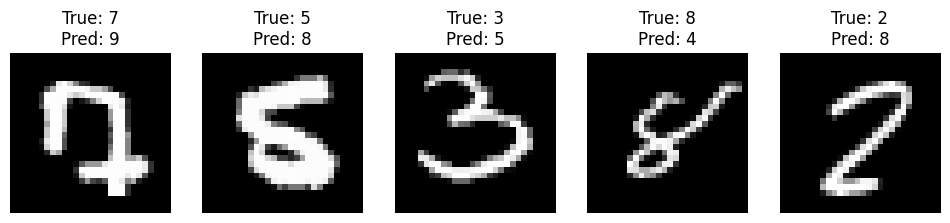

In [15]:
# misclassified counts and digits calculation 3.2.4
misclassified_counts = np.sum(cm, axis=1) - np.diag(cm)
most_misclassified_digits = np.argsort(misclassified_counts)[::-1]  # sort from most to least

print("Most Frequently Misclassified Digits in order:", most_misclassified_digits)

#  5 random misclassified examples 3.2.5
print("\n5 random misclassifed examples:")
misclassified_indices = np.where(y_test != y_test_pred)[0]
random_indices = np.random.choice(misclassified_indices, 5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(12, 4))
for i, ax in enumerate(axes):
    idx = random_indices[i]
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')  # Ensuring the shape is correct for visualization
    ax.set_title(f"True: {y_test[idx]}\nPred: {y_test_pred[idx]}")
    ax.axis("off")

plt.show()

In [17]:
# DECISION TREE PART
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

# 4.1 Model Training and Hyperparameter Tuning

class_names = [str(i) for i in range(10)]  # Digits 0-9

# define hyperparameter grid
param_grid = {
    'max_depth': [2, 5, 10],
    'min_samples_split': [2, 5]
}

# init decision tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# grid search performing
grid_search = GridSearchCV(
    estimator=dt_classifier,
    param_grid=param_grid,
    cv=3,  # Cross-validation folds
    scoring='accuracy',
    return_train_score=True  # Ensures we get both training and validation scores
)


# fit the grid search
grid_search.fit(X_train_final, y_train_final)

# store the results
results = grid_search.cv_results_

# display results for each hyperparameter
print("\nGrid Search Results:")
for i in range(len(results['params'])):
    print(f"Params: {results['params'][i]} | Mean Validation Accuracy: {results['mean_test_score'][i]:.4f}")

# extract best parameters
best_params = grid_search.best_params_
print(f"\nBest Hyperparameters: {best_params}")
print(f"Best Accuracy: {grid_search.best_score_:.4f}")
#best is with max depth 10 and min sample split 2




Grid Search Results:
Params: {'max_depth': 2, 'min_samples_split': 2} | Mean Validation Accuracy: 0.3408
Params: {'max_depth': 2, 'min_samples_split': 5} | Mean Validation Accuracy: 0.3408
Params: {'max_depth': 5, 'min_samples_split': 2} | Mean Validation Accuracy: 0.6639
Params: {'max_depth': 5, 'min_samples_split': 5} | Mean Validation Accuracy: 0.6639
Params: {'max_depth': 10, 'min_samples_split': 2} | Mean Validation Accuracy: 0.8501
Params: {'max_depth': 10, 'min_samples_split': 5} | Mean Validation Accuracy: 0.8501

Best Hyperparameters: {'max_depth': 10, 'min_samples_split': 2}
Best Accuracy: 0.8501


In [18]:
# 4.2 Evaluation
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import label_binarize


best_dt_classifier = DecisionTreeClassifier(random_state=42, **best_params)
best_dt_classifier.fit(X_train_final, y_train_final)

# evaluate on test set
y_test_pred = best_dt_classifier.predict(X_test_flat)

#4.2.1
# classification report
print("\nClassification Report for Decision Tree:")
print(classification_report(y_test, y_test_pred, target_names= class_names))




Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       980
           1       0.95      0.96      0.95      1135
           2       0.85      0.84      0.84      1032
           3       0.82      0.84      0.83      1010
           4       0.86      0.85      0.86       982
           5       0.84      0.80      0.82       892
           6       0.91      0.87      0.89       958
           7       0.90      0.88      0.89      1028
           8       0.80      0.81      0.80       974
           9       0.81      0.86      0.83      1009

    accuracy                           0.87     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.87      0.87     10000




Confusion Matrix for Decision Tree:
[[ 919    0   10    7    6   11    7    4   13    3]
 [   1 1089   12   13    2    5    2    1   10    0]
 [  15   11  864   20   22    8   12   34   35   11]
 [   7    5   39  845    6   47    2   19   23   17]
 [   3    4    7    7  832    7   12    8   28   74]
 [  16    9    5   51   14  717   20    8   29   23]
 [  23    5   13    7   34   17  833    3   21    2]
 [   3   14   26   10   10    4    0  906   11   44]
 [   9   10   30   40   14   21   19    9  791   31]
 [  13    2    8   32   24   14    5   13   31  867]]

Most Frequently Misclassified Digits in order: [8 5 2 3 4 9 6 7 0 1]




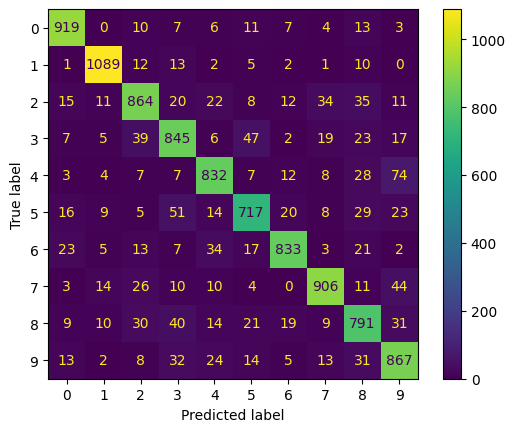

In [19]:
# confusion matrix 4.2.2

conf_matrix = confusion_matrix(y_test, y_test_pred)

print("\nConfusion Matrix for Decision Tree:")
print(conf_matrix)

# We can visualize the confusion matrix : in recitation we are using ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_test_pred)


# check most misclassified digits
misclassified_counts = np.sum(conf_matrix, axis=1) - np.diag(conf_matrix)
most_misclassified_digits = np.argsort(misclassified_counts)[::-1]  # sort from most to least

print("\nMost Frequently Misclassified Digits in order:", most_misclassified_digits)
print("\n")

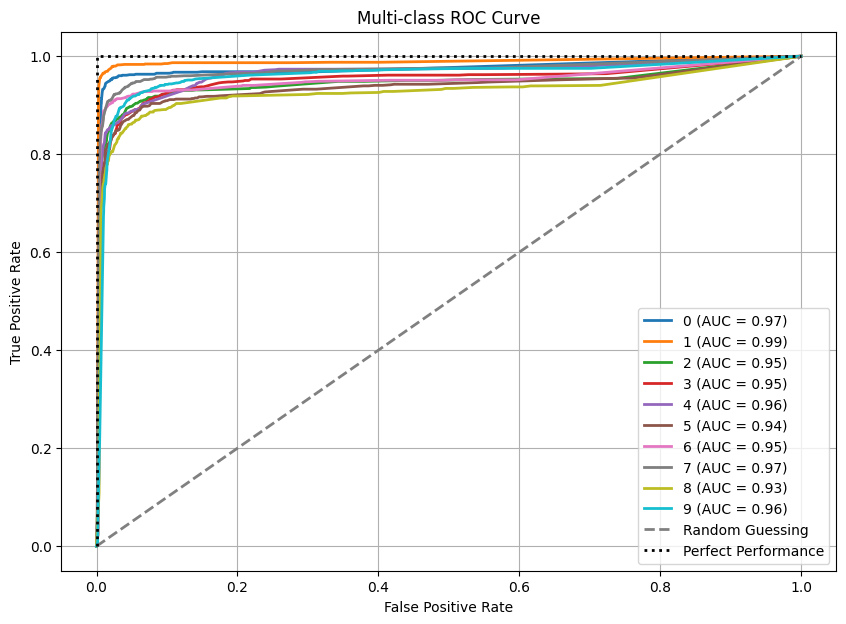

In [20]:
# 4.2.3 ROC curve visualizing
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
import numpy as np

class_names = [str(i) for i in range(10)]  # Digits 0-9
y_test_proba = best_dt_classifier.predict_proba(X_test_flat)

def plot_multiclass_roc_curve(y_true, y_proba, class_names):
    # Binarize the labels for multi-class ROC computation (Creating Negative - Positive predictions)
    y_true_bin = label_binarize(y_true, classes=np.arange(len(class_names)))

    plt.figure(figsize=(10, 7))
    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i]) # Always use the probabilities instead of the predictions
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})", lw=2)

    # Reference lines
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guessing", lw=2)
    plt.plot([0, 0, 1], [0, 1, 1], linestyle=":", color="black", label="Perfect Performance", lw=2)

    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Multi-class ROC Curve")
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

plot_multiclass_roc_curve(y_test, y_test_proba, class_names)

